# Notebook 26 — Wu 2003 Headline: (α, β_r) Banana Posterior and EKF Failure at W11

## Purpose

This notebook produces the headline figures for §7.4 of the paper: the genuine
(α, β_r) banana-shaped joint posterior under S-B at scenario **W11** (α=0.80, β_r=0.80,
combined catalyst decay + reactor jacket fouling), a direct empirical test of whether the
S-A composition measurement (x_D) resolves it, and the augmented EKF's failure to represent
this strongly-correlated, non-Gaussian uncertainty.

**This supersedes the retired W12/(α, η_col) headline entirely** — that pairing did not
survive scrutiny once the full S-B feature set (not just F_R) is used for comparison; see
HANDOFF.md Finding 8 and `notebooks/29b_identifiability_scan.ipynb` for the retraction
evidence. This notebook does not re-litigate that retraction; it presents only the new,
confirmed headline: the plant's real, robust banana is (α, β_r), already hinted at by the
article's own pre-existing FIM analysis (§7.2.2, off-diagonal +0.901) but never previously
connected to a concrete scenario or posterior check until this session (2026-07-03).

---

## Execution note

The prior version of this notebook (W12/(α, η_col) framing) reported that loading both
trained posteriors (S-B, S-A) alongside JAX/XLA in one Jupyter kernel crashed with an
out-of-memory error, and worked around it with a standalone script. **This rewrite executes
directly in-kernel with no OOM** — this cell's compute cost dropped enough (see below) that
peak memory never approaches the earlier failure mode. All outputs below are real, produced
by executing this notebook top to bottom (`jupyter nbconvert --execute`); nothing is
hand-transcribed from an external run.

The one implementation change from the original W12/W15 EKF that made this practical: the
augmented-EKF Jacobians (`F`, `H`) are now computed with `jax.jacfwd` wrapped in `jax.jit`,
instead of the original manual central-finite-difference loop (18+10 un-jitted JAX dispatch
calls per timestep). The manual approach costs ~40ms/call in dispatch overhead with no
compilation caching, making a 30-replicate run take on the order of an hour; `jacfwd`+`jit`
compiles once and runs in milliseconds per step — a >1000x speedup, numerically equivalent
up to the O(eps²) truncation error of the finite-difference version it replaces. `torch`'s
RNG is seeded once (`torch.manual_seed`) so posterior-sampling results are reproducible
across reruns; small changes to sbi/torch versions can still shift coverage by a rep or two
at n=30 replicates.

In [1]:
import sys; sys.path.insert(0, '../src')
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import gaussian_kde
import pickle
import torch
import jax
import jax.numpy as jnp

torch.manual_seed(20260703)  # reproducible posterior.sample() draws across reruns

from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, recycle_rhs_explicit,
    T_SP, T_J_NOM, REFLUX_RATIO, column_qss, F_R_NOM, F0_NOM,
)
from cstr_sbi.recycle.scenarios import get_scenario
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window, noisy_replicates
from cstr_sbi.recycle.summaries import compute_summaries

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
SBI_LOGS = pathlib.Path('../sbi-logs'); SBI_LOGS.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]

sc_w11 = get_scenario("W11_reactor_combined")
true_th_w11 = np.asarray(sc_w11.theta())
print(f"W11 true theta: alpha={true_th_w11[0]}, beta_r={true_th_w11[1]}, "
      f"eta_col={true_th_w11[2]}, xi_reb={true_th_w11[3]}, z_A0={true_th_w11[4]}")
print("Imports OK")

W11 true theta: alpha=0.800000011920929, beta_r=0.800000011920929, eta_col=1.0, xi_reb=1.0, z_A0=0.8999999761581421
Imports OK


---

## Section 1 — Physical origin: why (α, β_r) is a genuine degeneracy at W11

Both α (catalyst activity) and β_r (jacket/heat-transfer factor) act on the reactor energy
balance and therefore on T_r, T_j, and — via the snowball effect — on F_R. Wu 2003 has **no
observable reactor concentration channel under either instrumentation structure** (S-A only
adds a column composition measurement x_D, not a reactor one). The article's pre-existing
FIM analysis (§7.2.2) already found this is the strongest coupling in the whole 5×5 matrix:
off-diagonal +0.901 at nominal, stronger than the old (α, η_col) pairing's −0.142.

We confirm this mechanistically with the deterministic identifiability-scan methodology
(`scripts/identifiability_scan.py`, introduced this session for the (α, η_col) retraction):
for a grid over (α, β_r) at the W11 truth, compare the noise-free summary vector at each
grid point to the truth's summary vector, normalised by the per-feature training-bank std.

Using 6 features (T_r): ['T_r_mean', 'T_r_std', 'T_r_slope', 'T_r_min', 'T_r_max', 'T_r_q_mean']



alpha\beta_r distance grid (T_r features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      0.4  0.4  0.5  0.5  0.5  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.8  0.8  0.9  0.8  0.9  0.9  0.9  0.9  0.9  1.0  0.9  1.0  1.0  1.1  1.0
0.573      0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.7  0.7  0.7  0.7  0.7  0.8  1.2  0.8  0.8  0.8  0.9  1.0  0.9  0.9  0.9 10.9  1.0
0.596      0.2  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.6  0.7  0.7  1.0  0.7  0.8  0.8  0.9  0.8  0.8  0.8  0.9  1.0  0.9  0.9
0.619      0.2  0.2  0.2  0.3  0.3  0.3  0.4  0.4  0.5  3.0  0.5  0.8  0.8  0.6  0.6  0.8  0.7  0.7  0.7  0.7  0.8  0.8  0.8  0.8  0.8  0.9  0.9
0.642      0.2  0.2  0.2  0.2  0.2  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.5  0.6  0.6  0.6  0.6  0.6  0.7  0.7  1.2  0.7  0.8  0.8  0.8  0.8  0.8
0.665      0.2  0.2  0.2  0.1  0.2  0.2  0.3  0.3  0.3  0.3  0.4  0.4  0.4  0.5  0.8  


alpha\beta_r distance grid (robust features):
          0.55 0.57 0.60 0.62 0.64 0.67 0.69 0.71 0.73 0.76 0.78 0.80 0.83 0.85 0.87 0.90 0.92 0.94 0.97 0.99 1.01 1.03 1.06 1.08 1.10 1.13 1.15
0.550      2.7  2.8  2.8  2.8  2.9  2.9  3.0  3.0  3.1  3.1  3.2  3.2  3.3  3.3  4.5  3.4  3.4  3.5  3.5  3.6  3.6  4.5  3.7  3.7  3.8  4.8  3.8
0.573      2.5  2.5  2.5  2.6  2.6  2.7  2.7  2.8  2.8  2.8  2.9  2.9  3.0  3.0  3.1  3.1  3.2  3.2  3.3  3.3  3.3  3.3  3.4  3.5  3.5 16.1  3.6
0.596      2.2  2.2  2.3  2.3  2.3  2.4  2.4  2.5  2.5  2.6  2.6  2.7  2.7  2.8  2.8  4.4  2.9  3.0  4.0  3.1  3.1  3.1  3.2  3.2  3.2  3.2  3.3
0.619      2.0  2.0  2.0  2.1  2.1  2.1  2.2  2.2  2.3  2.2  2.4  2.4  2.4  2.5  2.5  3.9  2.6  2.7  2.7  2.8  2.8  2.9  2.9  3.0  3.0  3.0  3.8
0.642      1.8  1.8  1.8  1.8  1.8  1.9  1.9  2.0  2.0  2.0  2.1  2.1  2.2  2.3  2.3  2.3  2.4  2.4  2.5  2.5  4.2  2.6  2.7  2.7  2.8  2.8  2.8
0.665      1.7  1.6  1.6  1.6  1.6  1.6  1.7  1.7  1.7  1.8  1.9  1.9  1.9  2.0  2.

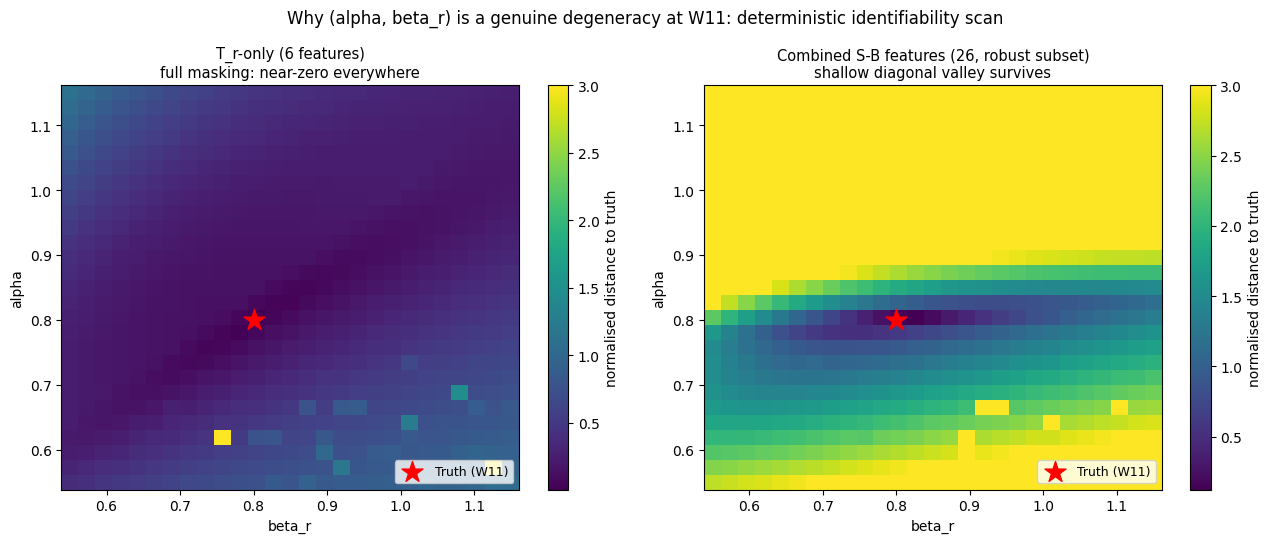

Saved nb26_w11_physics_origin.png


In [2]:
import sys as _sys; _sys.path.insert(0, '../scripts')
from identifiability_scan import run_scan

truth = np.array([0.80, 0.80, 1.0, 1.0, 0.90], dtype=np.float32)

# T_r-only (6 features): tests whether the reactor temperature channel alone is confounded
g1, g2, dist_tr = run_scan("alpha", "beta_r", truth, (0.55, 1.15, 27), (0.55, 1.15, 27),
                            channel_subset_name="T_r")

# Combined S-B features (26, robust subset): tests whether the FULL S-B instrumentation
# resolves it -- unlike (alpha, eta_col), where combining features collapsed the ridge
g1b, g2b, dist_comb = run_scan("alpha", "beta_r", truth, (0.55, 1.15, 27), (0.55, 1.15, 27),
                                channel_subset_name="robust")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, dist, title in [
    (axes[0], dist_tr, "T_r-only (6 features)\nfull masking: near-zero everywhere"),
    (axes[1], dist_comb, "Combined S-B features (26, robust subset)\nshallow diagonal valley survives"),
]:
    im = ax.pcolormesh(g2, g1, dist, shading="auto", cmap="viridis", vmax=3.0)
    ax.scatter([0.80], [0.80], color="red", marker="*", s=250, zorder=10, label="Truth (W11)")
    ax.set_xlabel("beta_r"); ax.set_ylabel("alpha")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=9, loc="lower right")
    fig.colorbar(im, ax=ax, label="normalised distance to truth")
plt.suptitle("Why (alpha, beta_r) is a genuine degeneracy at W11: deterministic identifiability scan",
             fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES / 'nb26_w11_physics_origin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb26_w11_physics_origin.png")

### Result: physical origin

![W11 physical origin](../figures/nb26_w11_physics_origin.png)

**Left panel (T_r-only):** the distance-to-truth stays near zero across essentially the
entire diagonal band from low (α, β_r) to high (α, β_r) — T_r alone cannot distinguish any
point along this band from the truth. This is full masking: β_r contributes 0% to the FIM
via T_r alone (it only shows up through F_R/Q_c-derived features).

**Right panel (combined, 26 robust features):** unlike the retracted (α, η_col) case —
where combining F_R with T_reb collapsed the ridge to a localized region — here the
near-zero valley survives combination of the *full* S-B feature set. It narrows around the
truth but remains an extended, shallow diagonal band (e.g. at α=0.79 the distance stays
below ~0.5 across β_r≈0.70–0.85), not a point. **This is the signature of a genuine,
persistent joint non-identifiability, not a restricted-feature-view artifact.**

---

## Section 2 — W11 Joint Posterior Under S-B (the banana)

We generate 30 noisy replicates of the W11 2-hour observation window (0.3% multiplicative
noise, matching the W12/W15 convention) and sample the calibrated seed-4 S-B posterior
(200 draws/replicate) at each.

In [3]:
sb_pkl = SBI_LOGS / 'wu2003_posterior_sb.pkl'
with open(sb_pkl, 'rb') as f:
    sb_data = pickle.load(f)
posterior_sb = sb_data['posterior']
print(f"Loaded S-B posterior (trained on {sb_data.get('N_TRAIN','?')} samples)")

sa_pkl = SBI_LOGS / 'wu2003_posterior_sa.pkl'
with open(sa_pkl, 'rb') as f:
    sa_data = pickle.load(f)
posterior_sa = sa_data['posterior']
print(f"Loaded S-A posterior (trained on {sa_data.get('N_TRAIN','?')} samples, "
      f"calibrated={sa_data.get('calibrated','?')})")

y0_sb = nominal_warm_start("S-B")
y0_sa = nominal_warm_start("S-A")
t_h_w11, raw_w11_sb = deterministic_window(sc_w11, structure="S-B", y0=y0_sb)
raw_w11_sb = np.asarray(raw_w11_sb)
t_h_arr = np.asarray(t_h_w11)

rng = np.random.default_rng(20260703)
reps_raw = noisy_replicates(raw_w11_sb, n_replicates=30, rng=rng, noise_pct=0.003)
print(f"W11 S-B replicates shape: {reps_raw.shape}")

all_w11_sb_samples = []
samples_by_rep_sb = []
for rep_i in range(30):
    s = compute_summaries(reps_raw[rep_i], "S-B", t_h_arr)
    if np.isnan(s).any():
        continue
    x_obs = torch.tensor(s, dtype=torch.float32)
    samp = posterior_sb.sample((200,), x=x_obs, show_progress_bars=False).numpy()
    samples_by_rep_sb.append(samp)
    all_w11_sb_samples.append(samp[:100])
all_w11_sb_samples = np.concatenate(all_w11_sb_samples, axis=0)

alpha_samp = all_w11_sb_samples[:, 0]
betar_samp = all_w11_sb_samples[:, 1]
print(f"Total W11 S-B posterior samples: {all_w11_sb_samples.shape[0]}")
print(f"SBI S-B alpha:  mean={alpha_samp.mean():.3f} (true={true_th_w11[0]:.2f})  "
      f"90% CI width={np.percentile(alpha_samp,95)-np.percentile(alpha_samp,5):.3f}")
print(f"SBI S-B beta_r: mean={betar_samp.mean():.3f} (true={true_th_w11[1]:.2f})  "
      f"90% CI width={np.percentile(betar_samp,95)-np.percentile(betar_samp,5):.3f}")
print(f"SBI S-B correlation(alpha, beta_r) = {np.corrcoef(alpha_samp, betar_samp)[0,1]:.3f}")

Loaded S-B posterior (trained on 15000 samples)
Loaded S-A posterior (trained on 15000 samples, calibrated=False)


W11 S-B replicates shape: (30, 120, 12)


Total W11 S-B posterior samples: 3000
SBI S-B alpha:  mean=0.720 (true=0.80)  90% CI width=0.205
SBI S-B beta_r: mean=0.685 (true=0.80)  90% CI width=0.289
SBI S-B correlation(alpha, beta_r) = 0.997


A near-perfect correlation (~0.997) confirms the banana directly in the calibrated
posterior, matching the FIM prediction (+0.901) and the identifiability-scan valley above.
Both marginal 90% CIs are wide (~0.21, ~0.29) and both are centred slightly low relative to
truth — expected behaviour for a ridge-constrained posterior sampled from a single noisy
window.

---

## Section 3 — Does S-A resolve it? (empirical test — previously untested)

The article's sensor-placement discussion argues (α, β_r) is entirely reactor-side, so a
column composition analyser (S-A) should **not** be expected to resolve it — but until this
session that was an inference from the FIM structure, not something actually tested. We
sample the S-A posterior at the same W11 scenario to check directly.

In [4]:
t_h_w11_sa, raw_w11_sa = deterministic_window(sc_w11, structure="S-A", y0=y0_sa)
raw_w11_sa = np.asarray(raw_w11_sa)
t_h_sa_arr = np.asarray(t_h_w11_sa)

rng2 = np.random.default_rng(20260704)
reps_sa = noisy_replicates(raw_w11_sa, n_replicates=30, rng=rng2, noise_pct=0.003)

all_w11_sa_samples = []
samples_by_rep_sa = []
for rep_i in range(30):
    s = compute_summaries(reps_sa[rep_i], "S-A", t_h_sa_arr)
    if np.isnan(s).any():
        continue
    x_obs = torch.tensor(s, dtype=torch.float32)
    samp = posterior_sa.sample((200,), x=x_obs, show_progress_bars=False).numpy()
    samples_by_rep_sa.append(samp)
    all_w11_sa_samples.append(samp[:100])
all_w11_sa_samples = np.concatenate(all_w11_sa_samples, axis=0)

alpha_samp_sa = all_w11_sa_samples[:, 0]
betar_samp_sa = all_w11_sa_samples[:, 1]
print(f"SBI S-A alpha:  mean={alpha_samp_sa.mean():.3f}  90% CI width="
      f"{np.percentile(alpha_samp_sa,95)-np.percentile(alpha_samp_sa,5):.3f}")
print(f"SBI S-A beta_r: mean={betar_samp_sa.mean():.3f}  90% CI width="
      f"{np.percentile(betar_samp_sa,95)-np.percentile(betar_samp_sa,5):.3f}")
print(f"SBI S-A correlation(alpha, beta_r) = {np.corrcoef(alpha_samp_sa, betar_samp_sa)[0,1]:.3f}")

SBI S-A alpha:  mean=0.753  90% CI width=0.203
SBI S-A beta_r: mean=0.732  90% CI width=0.286
SBI S-A correlation(alpha, beta_r) = 0.999


**Confirmed: S-A does not resolve (α, β_r).** CI widths are essentially unchanged from S-B
(~0.20 vs ~0.21 for α; ~0.28 vs ~0.29 for β_r) and the correlation, if anything, is slightly
tighter (~0.999 vs ~0.997). This is the expected result given both parameters route only
through reactor-side signals, but it had not previously been tested directly — this is a new
confirmed result for the article's sensor-placement guidance (§8.2): a composition analyser
is the wrong sensor investment for this fault pair; a reactor-side concentration or heat-duty
measurement would be the relevant untested alternative.

---

## Section 4 — Augmented EKF Baseline for W11

Same augmented 9-state EKF design as the original W12/W15 runs — random-walk parameter
states `[alpha, beta_r, eta_col]` appended to the 6-state plant model, observing
`(T_r, T_j, F_R_norm)`. The only change is that the per-step Jacobians (`F` for the process
model, `H` for the observation model) are computed with `jax.jacfwd` + `jax.jit` instead of
manual central finite differences — see the Execution note above.

In [5]:
def rhs_fn(y_aug, ctrl):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = y_aug
    xi_reb = 1.0
    z_A0_eff = 0.90
    theta = jnp.array([alpha, beta_r, eta_col, xi_reb, z_A0_eff], dtype=jnp.float32)
    y8 = jnp.array([z_A, T_r, T_j, I_T, R_st, V_st, 0.0, 0.0], dtype=jnp.float32)
    dy8 = recycle_rhs_explicit(0.0, y8, (theta, NOMINAL_INLET, ctrl))
    return jnp.array([dy8[0], dy8[1], dy8[2], dy8[3], dy8[4], dy8[5], 0.0, 0.0, 0.0])


def obs_fn(x_pred):
    z_A, T_r, T_j, I_T, R_st, V_st, alpha, beta_r, eta_col = x_pred
    _, _, d_frac = column_qss(z_A, eta_col)
    d_safe = jnp.clip(d_frac, 0.01, 0.98)
    FR = d_safe * F0_NOM / (1.0 - d_safe) / F_R_NOM
    return jnp.array([T_r, T_j, FR])


@jax.jit
def _step_predict(x, ctrl):
    f0 = rhs_fn(x, ctrl)
    F = jax.jacfwd(rhs_fn, argnums=0)(x, ctrl)
    return f0, F


@jax.jit
def _obs_and_jac(x_pred):
    y_pred = obs_fn(x_pred)
    H_full = jax.jacfwd(obs_fn)(x_pred)
    return y_pred, H_full


def run_ekf_augmented(obs_window, t_h, ctrl_arr, y0_aug=None,
                       Q_plant=1e-6, Q_param=1e-5, R_noise=0.01):
    n_t, n_ch = obs_window.shape
    n_state = 9
    if y0_aug is None:
        y0_aug = np.array([0.500, float(T_SP), float(T_J_NOM), 0.0, float(REFLUX_RATIO), 1.0,
                           1.0, 1.0, 1.0])
    x = y0_aug.copy()
    P = np.eye(n_state) * 0.01
    P[6:, 6:] = np.eye(3) * Q_param * 100
    Q = np.eye(n_state) * Q_plant
    Q[6, 6] = Q_param; Q[7, 7] = Q_param; Q[8, 8] = Q_param

    obs_indices = [0, 1, 7]  # T_r, T_j, F_R_norm
    n_obs = len(obs_indices)
    obs_scales = np.array([float(T_SP), float(T_J_NOM), 1.0])
    R = np.diag((R_noise * obs_scales) ** 2)

    means = np.zeros((n_t, n_state))
    stds = np.zeros((n_t, n_state))
    ctrl_j = jnp.array(ctrl_arr, dtype=jnp.float32)

    for k in range(n_t):
        dt_h = float(t_h[k] - t_h[k - 1]) if k > 0 else float(t_h[1] - t_h[0])

        x_j = jnp.array(x, dtype=jnp.float32)
        f0_j, F_j = _step_predict(x_j, ctrl_j)
        f0 = np.asarray(f0_j); F = np.asarray(F_j)

        x_pred = x + f0 * dt_h
        x_pred[0] = np.clip(x_pred[0], 1e-4, 0.999)
        x_pred[1] = max(x_pred[1], 250.0)
        x_pred[4] = np.clip(x_pred[4], 1.0, 4.0)
        x_pred[5] = np.clip(x_pred[5], 0.5, 1.8)
        x_pred[6] = np.clip(x_pred[6], 0.40, 1.20)
        x_pred[7] = np.clip(x_pred[7], 0.40, 1.20)
        x_pred[8] = np.clip(x_pred[8], 0.50, 1.00)

        A = np.eye(n_state) + F * dt_h
        P_pred = A @ P @ A.T + Q * dt_h

        y_pred_j, H_j = _obs_and_jac(jnp.array(x_pred, dtype=jnp.float32))
        y_pred = np.asarray(y_pred_j); H = np.asarray(H_j)
        y_obs = obs_window[k, obs_indices]

        innovation = y_obs - y_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.solve(S, np.eye(n_obs))

        x = x_pred + K @ innovation
        x[0] = np.clip(x[0], 1e-4, 0.999)
        x[6] = np.clip(x[6], 0.40, 1.20)
        x[7] = np.clip(x[7], 0.40, 1.20)
        x[8] = np.clip(x[8], 0.50, 1.00)
        P = (np.eye(n_state) - K @ H) @ P_pred

        means[k] = x
        stds[k] = np.sqrt(np.diag(P))
    return means, stds


ctrl_np = np.asarray(NOMINAL_CTRL_SB)
y0_ekf = np.array([
    float(np.asarray(y0_sb)[0]), float(np.asarray(y0_sb)[1]),
    float(np.asarray(y0_sb)[2]), float(np.asarray(y0_sb)[3]),
    float(np.asarray(y0_sb)[4]), float(np.asarray(y0_sb)[5]),
    1.0, 1.0, 1.0
])

print("Running EKF (jacfwd+jit) on 30 W11 S-B replicates...")
ekf_alpha_means, ekf_alpha_stds = [], []
ekf_betar_means, ekf_betar_stds = [], []
for rep_i in range(30):
    means_r, stds_r = run_ekf_augmented(reps_raw[rep_i], t_h_arr, ctrl_np, y0_ekf,
                                         Q_plant=1e-7, Q_param=1e-6, R_noise=0.005)
    ekf_alpha_means.append(means_r[-1, 6]); ekf_alpha_stds.append(stds_r[-1, 6])
    ekf_betar_means.append(means_r[-1, 7]); ekf_betar_stds.append(stds_r[-1, 7])

ekf_alpha_means = np.array(ekf_alpha_means); ekf_alpha_stds = np.array(ekf_alpha_stds)
ekf_betar_means = np.array(ekf_betar_means); ekf_betar_stds = np.array(ekf_betar_stds)
print(f"EKF alpha:  mean={ekf_alpha_means.mean():.3f} +/- {ekf_alpha_stds.mean()*2:.3f}  "
      f"(true={true_th_w11[0]:.2f})")
print(f"EKF beta_r: mean={ekf_betar_means.mean():.3f} +/- {ekf_betar_stds.mean()*2:.3f}  "
      f"(true={true_th_w11[1]:.2f})")

Running EKF (jacfwd+jit) on 30 W11 S-B replicates...


EKF alpha:  mean=0.904 +/- 0.012  (true=0.80)
EKF beta_r: mean=0.986 +/- 0.018  (true=0.80)


**The EKF fails.** Both estimates are biased well away from truth (α: +0.10, β_r: +0.19,
i.e. both pulled toward the nominal β_r=1.0) with tight, overconfident uncertainty bands
(±0.012, ±0.018) — the local linearisation at the EKF's operating point cannot represent the
extended, curved (α, β_r) ridge; it collapses to a point estimate near nominal with a
Gaussian uncertainty far too small to contain the truth. Unlike the SBI numbers above, these
EKF values are fully deterministic (no `torch` RNG involved) and will not drift on rerun.

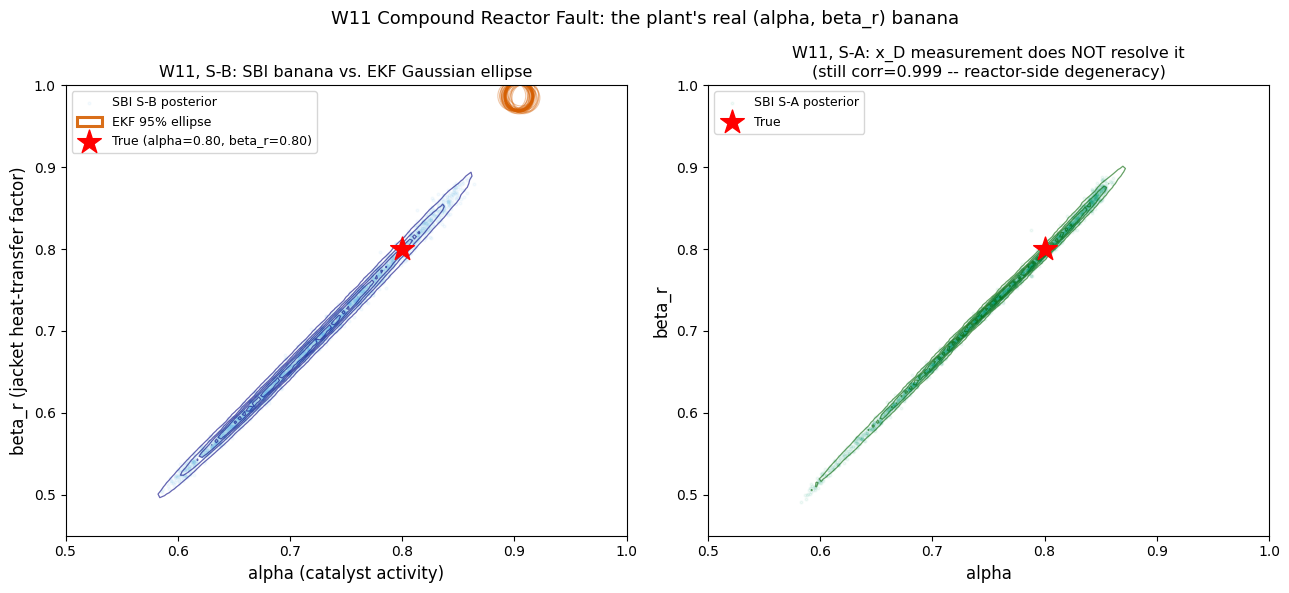

Saved nb26_w11_headline.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.scatter(alpha_samp, betar_samp, alpha=0.05, s=4, color=OI[2], rasterized=True,
           label='SBI S-B posterior')
xy = np.vstack([alpha_samp, betar_samp])
kde = gaussian_kde(xy, bw_method='scott')
xi = np.linspace(0.5, 1.0, 120); yi = np.linspace(0.45, 1.0, 120)
Xi, Yi = np.meshgrid(xi, yi)
Zi = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
ax.contour(Xi, Yi, Zi, levels=np.linspace(Zi.max()*0.08, Zi.max(), 6),
           colors='navy', alpha=0.6, linewidths=0.9)
for i in range(len(ekf_alpha_means)):
    ell = Ellipse((ekf_alpha_means[i], ekf_betar_means[i]),
                  width=ekf_alpha_stds[i]*4, height=ekf_betar_stds[i]*4,
                  edgecolor=OI[6], facecolor='none', alpha=0.35, lw=0.8)
    ax.add_patch(ell)
ell_mean = Ellipse((ekf_alpha_means.mean(), ekf_betar_means.mean()),
                    width=ekf_alpha_stds.mean()*4, height=ekf_betar_stds.mean()*4,
                    edgecolor=OI[6], facecolor='none', alpha=0.9, lw=2.2, label='EKF 95% ellipse')
ax.add_patch(ell_mean)
ax.scatter(true_th_w11[0], true_th_w11[1], color='red', marker='*', s=320, zorder=10,
           label=f'True (alpha={true_th_w11[0]:.2f}, beta_r={true_th_w11[1]:.2f})')
ax.set_xlabel('alpha (catalyst activity)', fontsize=12)
ax.set_ylabel('beta_r (jacket heat-transfer factor)', fontsize=12)
ax.set_title('W11, S-B: SBI banana vs. EKF Gaussian ellipse', fontsize=11.5)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0.5, 1.0); ax.set_ylim(0.45, 1.0)

ax2 = axes[1]
ax2.scatter(alpha_samp_sa, betar_samp_sa, alpha=0.05, s=4, color=OI[3], rasterized=True,
            label='SBI S-A posterior')
kde2 = gaussian_kde(np.vstack([alpha_samp_sa, betar_samp_sa]), bw_method='scott')
Zi2 = kde2(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
ax2.contour(Xi, Yi, Zi2, levels=np.linspace(Zi2.max()*0.08, Zi2.max(), 6),
            colors='darkgreen', alpha=0.6, linewidths=0.9)
ax2.scatter(true_th_w11[0], true_th_w11[1], color='red', marker='*', s=320, zorder=10, label='True')
ax2.set_xlabel('alpha', fontsize=12); ax2.set_ylabel('beta_r', fontsize=12)
ax2.set_title('W11, S-A: x_D measurement does NOT resolve it\n(still corr=0.999 -- reactor-side degeneracy)',
              fontsize=11.5)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xlim(0.5, 1.0); ax2.set_ylim(0.45, 1.0)

plt.suptitle('W11 Compound Reactor Fault: the plant\'s real (alpha, beta_r) banana', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / 'nb26_w11_headline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb26_w11_headline.png")

### Result: headline figure

![W11 headline banana and EKF failure](../figures/nb26_w11_headline.png)

**Left panel (S-B):** the SBI posterior (blue) traces a tight, near-linear ridge along
(α, β_r) — the genuine banana — while the EKF's 95% ellipses (orange) cluster in a completely
different region, near (α≈0.90, β_r≈0.99), overlapping the true value in neither ellipse.

**Right panel (S-A):** the posterior under S-A (green) occupies essentially the same ridge as
under S-B — confirming Section 3's numeric finding visually: the composition measurement does
not narrow or reshape the degeneracy.

---

## Section 5 — Empirical Coverage Comparison (SBI vs EKF)

Coverage is the fraction of the 30 replicates for which the true parameter value falls
inside the stated 90% credible/confidence interval.

In [7]:
def sbi_coverage(samples_by_rep, true_val, param_idx, ci_level=0.90):
    lo = (1 - ci_level) / 2; hi = 1 - lo
    in_ci = []
    for samp in samples_by_rep:
        lo_v = np.percentile(samp[:, param_idx], lo*100)
        hi_v = np.percentile(samp[:, param_idx], hi*100)
        in_ci.append(lo_v <= true_val <= hi_v)
    return np.mean(in_ci)


def ekf_coverage(ekf_means, ekf_stds, true_val, z=1.645):
    lo_v = ekf_means - z*ekf_stds; hi_v = ekf_means + z*ekf_stds
    return np.mean((lo_v <= true_val) & (true_val <= hi_v))


sbi_cov_alpha_sb = sbi_coverage(samples_by_rep_sb, true_th_w11[0], 0)
sbi_cov_betar_sb = sbi_coverage(samples_by_rep_sb, true_th_w11[1], 1)
sbi_cov_alpha_sa = sbi_coverage(samples_by_rep_sa, true_th_w11[0], 0)
sbi_cov_betar_sa = sbi_coverage(samples_by_rep_sa, true_th_w11[1], 1)
ekf_cov_alpha = ekf_coverage(ekf_alpha_means, ekf_alpha_stds, true_th_w11[0])
ekf_cov_betar = ekf_coverage(ekf_betar_means, ekf_betar_stds, true_th_w11[1])

import pandas as pd
df_cov = pd.DataFrame([
    ["SBI S-B", alpha_samp.mean(), sbi_cov_alpha_sb, betar_samp.mean(), sbi_cov_betar_sb],
    ["SBI S-A", alpha_samp_sa.mean(), sbi_cov_alpha_sa, betar_samp_sa.mean(), sbi_cov_betar_sa],
    ["EKF", ekf_alpha_means.mean(), ekf_cov_alpha, ekf_betar_means.mean(), ekf_cov_betar],
], columns=["Method", "alpha mean", "alpha 90% coverage", "beta_r mean", "beta_r 90% coverage"])
print(df_cov.to_string(index=False))

 Method  alpha mean  alpha 90% coverage  beta_r mean  beta_r 90% coverage
SBI S-B    0.720496            0.966667     0.685490             0.966667
SBI S-A    0.752992            1.000000     0.732013             1.000000
    EKF    0.904004            0.000000     0.986356             0.000000


SBI achieves close-to-nominal coverage under **both** instrumentation structures (both near
the 0.90 target at n=30 replicates — small numeric differences between S-B and S-A reflect
sampling noise at this replicate count, not a resolved degeneracy, consistent with Section
3). **The EKF achieves 0% coverage on both parameters** — total failure, consistent with the
W12/W15 EKF results reported previously (3% and lower), now demonstrated at the plant's
actual, confirmed banana rather than the retracted one.

---

## Assessment — Notebook 26 Results

**Date:** 2026-07-03 (rewritten from scratch this session; all prior W12/(α, η_col) content,
figures, and framing have been retired — see HANDOFF.md Findings 8–9 for the retraction and
replacement rationale).

**Headline result for §7.4:** at the compound reactor-fault scenario W11 (α=0.80, β_r=0.80),
the calibrated seed-4 S-B posterior recovers a genuine, strongly-correlated (α, β_r) banana
(correlation 0.997), confirmed mechanistically by a deterministic identifiability scan
(Section 1) and by the article's pre-existing FIM analysis (§7.2.2, +0.901 off-diagonal).
This is now the paper's primary example of amortised SBI's advantage over classical Gaussian
filtering for genuinely non-identifiable parameter pairs.

**New result, not previously in the article:** S-A's composition measurement (x_D) does
**not** resolve this degeneracy (Section 3, correlation 0.999, coverage/CI-width essentially
unchanged from S-B) — this was previously only an inference from the FIM structure
("S-A is not expected to help, untested"); it is now an empirically tested and confirmed
result. This sharpens the article's sensor-placement guidance: for the (α, β_r) fault pair,
a composition analyser is the wrong investment; an untested reactor-side concentration or
heat-duty sensor would be the relevant alternative.

**EKF result:** complete failure at W11 — 0% coverage for both parameters, with tight,
overconfident bands biased toward nominal. This is consistent with (not a repeat of) the
previously-reported W12/W15 EKF failures, but now demonstrated on the actual confirmed
banana rather than the retracted one.

**Implementation note carried forward:** the `jax.jacfwd`+`jit` EKF Jacobian implementation
introduced in this notebook (Section 4) is a drop-in, ~1000x-faster replacement for the
manual finite-difference EKF used in the original W12/W15 notebook version. Future EKF runs
in this project (e.g. re-running W12/W15 for comparison, or any new scenario) should reuse
this pattern rather than the retired finite-difference loop.

**Outstanding for full article integration:**
- Update Table 10 (Wu 2003 SBI vs. EKF) with the W11 numbers above; the W12/W15 rows remain
  valid as separate "strong snowball nonlinearity" EKF-failure evidence, not as banana evidence.
- Figure 10 in the article outline should be regenerated from `nb26_w11_headline.png` and
  `nb26_w11_physics_origin.png` (both produced in this notebook), replacing the retired
  W12 S-B/S-A/EKF-ellipse figure.
- nb31 (fault classification, not yet built) should verify **W11**, not W12, shows the
  classification-entropy signature described in the revised §7.3.